# TRAPPIST-1 b y c: rocas desnudas a 40 años-luz

490 kelvin de día. Cero emisión de noche. Así se ve un planeta sin atmósfera.

**Paper:** Ducrot, E., Gillon, M., Demory, B.-O. *et al.* No thick atmosphere around TRAPPIST-1 b and c from JWST thermal phase curves. *Nature Astronomy* (2026).
**DOI:** [10.1038/s41550-026-02806-9](https://doi.org/10.1038/s41550-026-02806-9)
**Datos:** [MAST (JWST Programme 3077)](https://mast.stsci.edu) + Supplementary Materials

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-03-trappist-1-sin-atmosfera-jwst/notebook.ipynb)

## El sistema más estudiado fuera del nuestro

TRAPPIST-1 está a ~40 años-luz. Una enana roja con siete planetas rocosos apretados en órbitas más pequeñas que la de Mercurio. Desde 2017, la gran pregunta es: ¿alguno tiene atmósfera?

El James Webb Space Telescope (JWST) observó los dos más cercanos a la estrella — TRAPPIST-1 b y c — durante más de 2 días continuos con su instrumento MIRI a 15 μm (infrarrojo medio). A esa longitud de onda, el telescopio detecta directamente el calor que irradian los planetas. Cuatro equipos analizaron los datos de forma independiente.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
T_DAY_B = 490       # Temperatura diurna planeta b (K) — headline del paper
T_DAY_C = 369       # Temperatura diurna planeta c (K)
T_NIGHT_B_MAX = 243  # Estimación máxima nocturna b (K, ZH sinusoidal)
T_NIGHT_C = 266      # Nocturna c (K, ZH quasi-Lambert)
T_STAR = 2566        # Temperatura de TRAPPIST-1 (K)

COLOR_B = '#DC2626'     # Rojo — planeta b (más caliente, más cercano)
COLOR_C = '#2563EB'     # Azul CaM — planeta c
COLOR_MODELO = '#059669' # Emerald — modelos atmosféricos
COLOR_REF = '#D97706'    # Amber — referencia
COLOR_GRIS = '#BBBBBB'

FUENTE = 'Fuente: Ducrot et al. (2026), Nature Astronomy | Datos: JWST MIRI 15 μm'

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
obs = pd.read_csv('datos/curva_fase_obs.csv')
modelo = pd.read_csv('datos/curva_fase_modelo.csv')
mcmc_b = pd.read_csv('datos/mcmc_chunk0.csv')
mcmc_c = pd.read_csv('datos/mcmc_chunk3.csv')
clima = pd.read_csv('datos/modelos_climaticos.csv')
temps = pd.read_csv('datos/temperaturas_analisis.csv')

print(f"Observaciones GO 3077: {len(obs)} puntos (bins de 15 min)")
print(f"Modelo best-fit: {len(modelo)} puntos")
print(f"Modelos climáticos: {len(clima)} escenarios atmosféricos")
print(f"Duración observación: {obs['time_bjd'].max() - obs['time_bjd'].min():.2f} días (~{(obs['time_bjd'].max() - obs['time_bjd'].min())*24:.0f} horas)")

Observaciones GO 3077: 207 puntos (bins de 15 min)
Modelo best-fit: 4501 puntos
Modelos climáticos: 12 escenarios atmosféricos
Duración observación: 2.18 días (~52 horas)


## La firma térmica de dos mundos

Aquí está. Más de 52 horas de observación continua con el JWST.

<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_566/3071807145.py:39: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('Tiempo (BJD$_{\mathrm{TDB}}$ − 2.450.000)', fontsize=11)


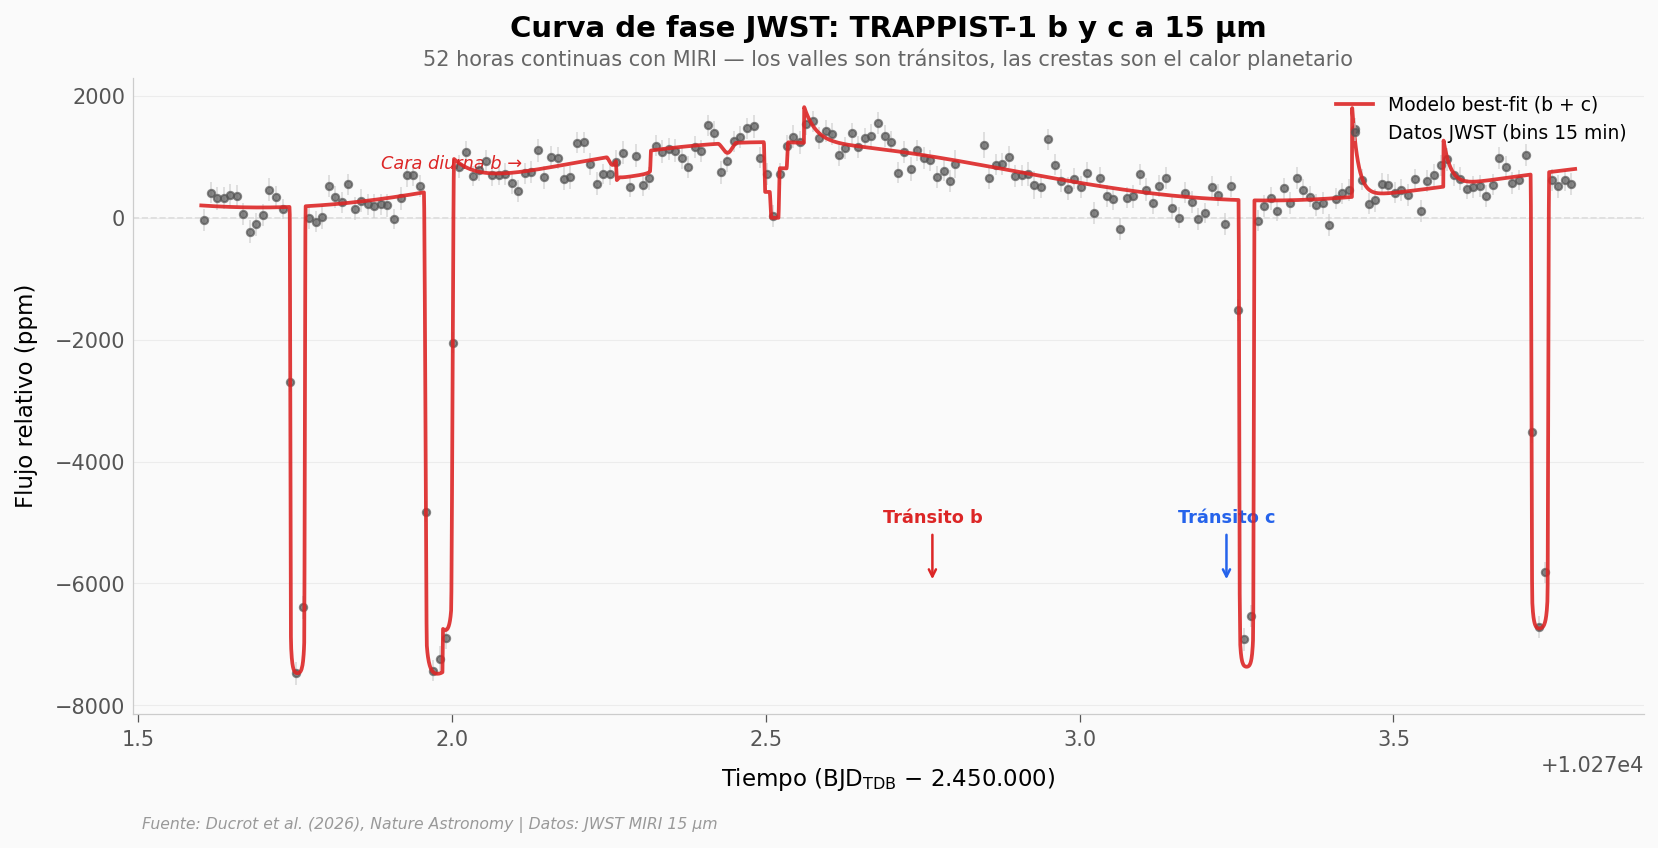

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Observaciones binned (15 min)
ax.errorbar(obs['time_bjd'], obs['flux_ppm'], yerr=obs['error_ppm'],
            fmt='o', color='#555555', markersize=3.5, alpha=0.7,
            ecolor='#CCCCCC', elinewidth=0.8, capsize=0, zorder=3,
            label='Datos JWST (bins 15 min)')

# Modelo best-fit
modelo_sorted = modelo.sort_values('time_bjd')
ax.plot(modelo_sorted['time_bjd'], modelo_sorted['flux_ppm'],
        color=COLOR_B, linewidth=1.8, alpha=0.9, zorder=4,
        label='Modelo best-fit (b + c)')

# Anotar tránsitos de planeta b (dips profundos ~7000 ppm)
# Transit times from SM Table 3: phase curve transit at BJD 10271.254
t_transit_b = 10271.254
P_b = 1.51154
for i in range(2):
    t = t_transit_b + i * P_b
    if obs['time_bjd'].min() < t < obs['time_bjd'].max():
        ax.annotate('Tránsito b', xy=(t, -6000), xytext=(t, -5000),
                    fontsize=8.5, color=COLOR_B, ha='center', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=COLOR_B, lw=1.2))

# Anotar tránsito de planeta c
t_transit_c = 10273.234
if obs['time_bjd'].min() < t_transit_c < obs['time_bjd'].max():
    ax.annotate('Tránsito c', xy=(t_transit_c, -6000), xytext=(t_transit_c, -5000),
                fontsize=8.5, color=COLOR_C, ha='center', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=COLOR_C, lw=1.2))

# Anotar fase diurna (máximo de flujo entre tránsitos)
ax.annotate('Cara diurna b →', xy=(10272.0, 800),
            fontsize=8.5, color=COLOR_B, ha='center', style='italic')

ax.axhline(y=0, color='#DDDDDD', linewidth=0.8, linestyle='--', zorder=1)

ax.set_xlabel('Tiempo (BJD$_{\mathrm{TDB}}$ − 2.450.000)', fontsize=11)
ax.set_ylabel('Flujo relativo (ppm)', fontsize=11)
ax.set_title('Curva de fase JWST: TRAPPIST-1 b y c a 15 μm',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '52 horas continuas con MIRI — los valles son tránsitos, las crestas son el calor planetario',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/curva_fase_jwst.png', dpi=200, bbox_inches='tight')
plt.show()

Los valles profundos (~7.000 ppm) son los **tránsitos**: cada planeta pasa frente a la estrella y bloquea luz. Pero lo que importa aquí es lo que pasa ENTRE los tránsitos.

Entre un tránsito y el siguiente, el flujo sube gradualmente. Eso es el calor del lado diurno del planeta irradiando hacia nosotros. Cuando el planeta muestra su "espalda" (lado nocturno), el flujo cae a cero. Esa diferencia entre cresta y valle nos dice si hay atmósfera redistribuyendo calor, o si el planeta es una roca desnuda.

Cuatro equipos independientes (MG, ED, TJB, ZH) ajustaron estos datos. Todos coinciden.

## ¿Cuánto calor? Día vs noche

Con el flujo medido calculamos la **temperatura de brillo**: cuán caliente está la superficie. Si hubiera una atmósfera densa redistribuyendo calor, la noche sería más templada. Veamos qué predicen los modelos climáticos para diferentes composiciones.

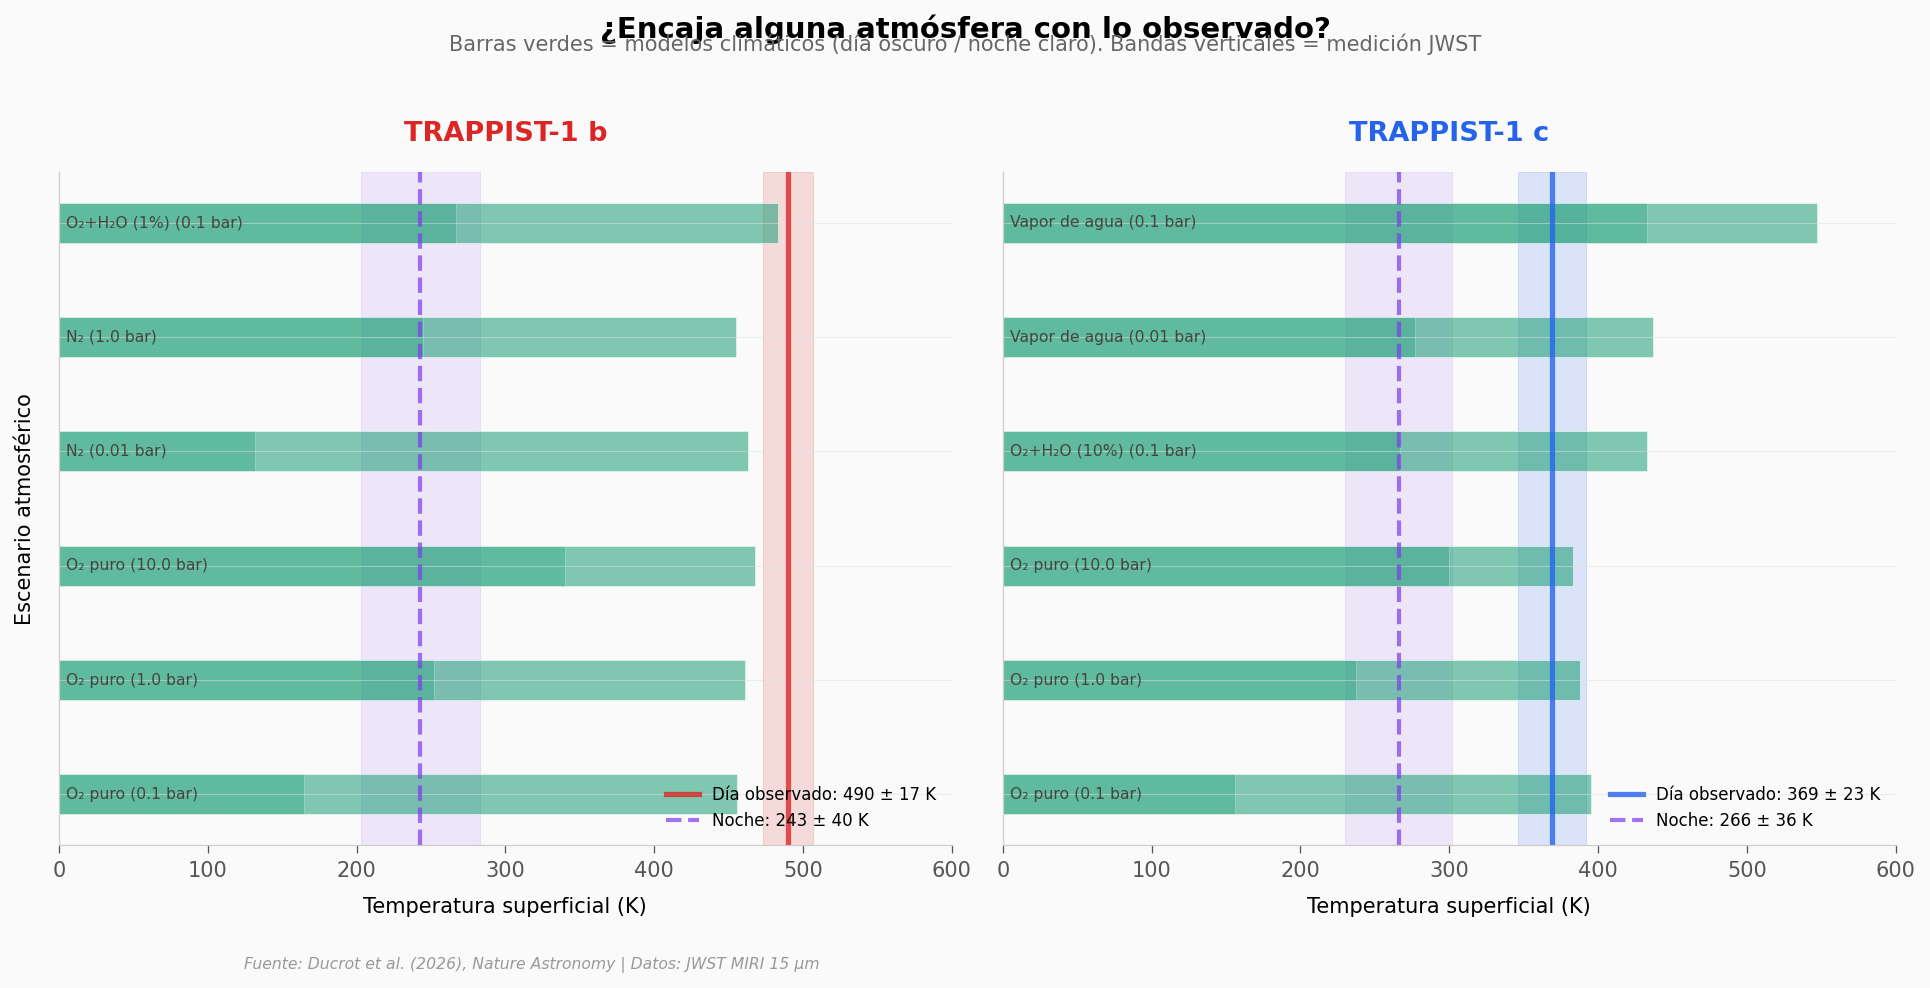

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for idx, (planet, ax, color, t_day, t_day_err, t_night, t_night_err) in enumerate([
    ('b', axes[0], COLOR_B, T_DAY_B, 17, T_NIGHT_B_MAX, 40),
    ('c', axes[1], COLOR_C, T_DAY_C, 23, T_NIGHT_C, 36)
]):
    # Modelos climáticos para este planeta
    models = clima[clima['planet'] == planet]

    # Plot atmospheric model predictions
    y_pos = list(range(len(models)))
    for i, (_, row) in enumerate(models.iterrows()):
        label_text = f"{row['environment']} ({row['pressure_bar']} bar)"
        # Day temperature
        ax.barh(i, row['T_day'], height=0.35, left=0, color=COLOR_MODELO,
                alpha=0.5, edgecolor='white', linewidth=0.5)
        # Night temperature
        ax.barh(i, row['T_night'], height=0.35, left=0, color=COLOR_MODELO,
                alpha=0.25, edgecolor='white', linewidth=0.5)
        ax.text(5, i, label_text, fontsize=7.5, va='center', color='#444444')

    # Observed values as vertical bands
    ax.axvspan(t_day - t_day_err, t_day + t_day_err, alpha=0.15, color=color, zorder=0)
    ax.axvline(t_day, color=color, linewidth=2.5, linestyle='-', alpha=0.8, zorder=5,
               label=f'Día observado: {t_day} ± {t_day_err} K')
    ax.axvspan(max(0, t_night - t_night_err), t_night + t_night_err,
               alpha=0.10, color='#7C3AED', zorder=0)
    ax.axvline(t_night, color='#7C3AED', linewidth=2, linestyle='--', alpha=0.7, zorder=5,
               label=f'Noche: {t_night} ± {t_night_err} K')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(['' for _ in y_pos])
    ax.set_xlabel('Temperatura superficial (K)', fontsize=10)
    ax.set_title(f'TRAPPIST-1 {planet}', fontsize=13, fontweight='bold', pad=15,
                 color=color)
    ax.legend(fontsize=8, loc='lower right', framealpha=0.9)
    ax.set_xlim(0, 600)
    ax.invert_yaxis()

axes[0].set_ylabel('Escenario atmosférico', fontsize=10)
fig.suptitle('¿Encaja alguna atmósfera con lo observado?',
             fontsize=14, fontweight='bold', y=1.03)
fig.text(0.5, 0.99, 'Barras verdes = modelos climáticos (día oscuro / noche claro). Bandas verticales = medición JWST',
         fontsize=10, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/temperaturas_vs_modelos.png', dpi=200, bbox_inches='tight')
plt.show()

Para TRAPPIST-1 b, ningún modelo atmosférico explica simultáneamente el lado diurno tan caliente (490 K) y el nocturno tan frío. Eso es exactamente lo que esperamos de una roca desnuda: absorbe todo el calor de un lado y lo reirradia, sin viento ni convección que lo redistribuya.

TRAPPIST-1 c es más sutil. Los datos encajan tanto con una superficie reflectante sin aire **como** con una atmósfera tenue rica en oxígeno (O₂ a ~0,1 bar). Con estos datos, no hay forma de distinguirlos — toca esperar más observaciones.

¿Qué tan precisa es la medición? Cada equipo corrió cadenas MCMC con >100.000 muestras. Veamos la distribución del flujo diurno.

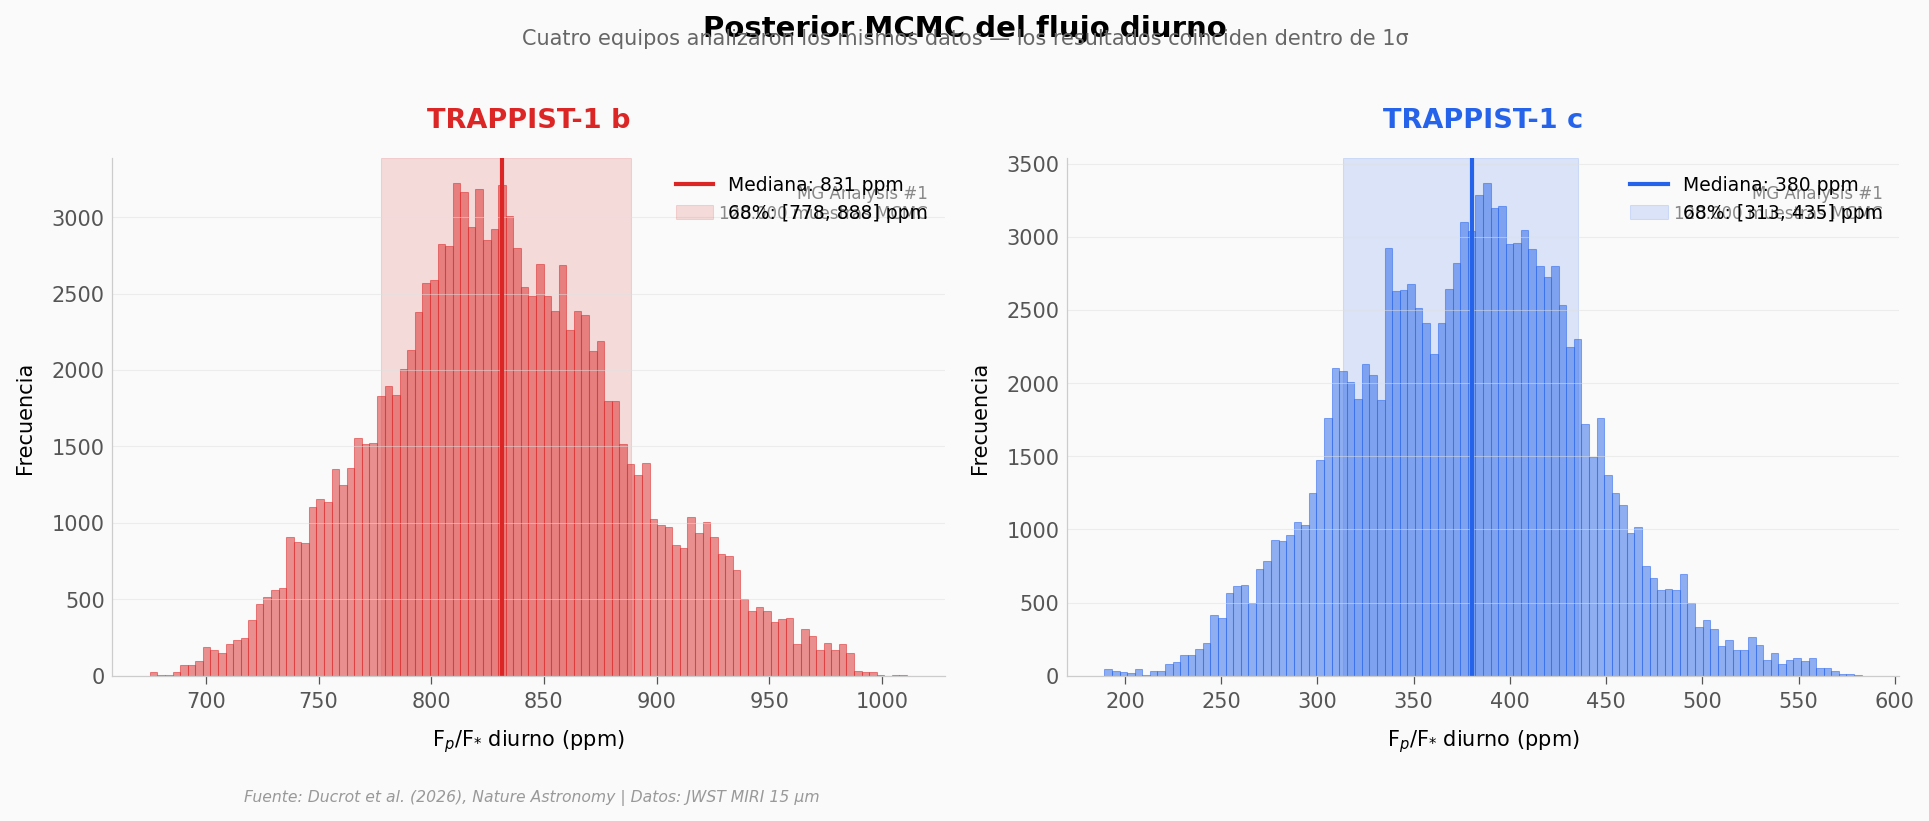

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, planet, color, paper_val in [
    (axes[0], mcmc_b, 'b', COLOR_B, 839.51),
    (axes[1], mcmc_c, 'c', COLOR_C, 392.19)
]:
    ax.bar(data['bin_center'], data['count'], width=np.diff(data['bin_center'].values[:2])[0] if len(data) > 1 else 10,
           color=color, alpha=0.5, edgecolor=color, linewidth=0.5)

    # Median and 68% interval
    # Reconstruct samples from histogram
    samples = np.repeat(data['bin_center'].values, data['count'].values.astype(int))
    med = np.median(samples)
    q16 = np.percentile(samples, 16)
    q84 = np.percentile(samples, 84)

    ax.axvline(med, color=color, linewidth=2, label=f'Mediana: {med:.0f} ppm')
    ax.axvspan(q16, q84, alpha=0.15, color=color,
               label=f'68%: [{q16:.0f}, {q84:.0f}] ppm')

    ax.set_xlabel(f'F$_{{p}}$/F$_{{*}}$ diurno (ppm)', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.set_title(f'TRAPPIST-1 {planet}', fontsize=13, fontweight='bold',
                 pad=15, color=color)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.text(0.98, 0.95, f'MG Analysis #1\n120.000 muestras MCMC',
            transform=ax.transAxes, fontsize=8, color='#888888',
            ha='right', va='top')

fig.suptitle('Posterior MCMC del flujo diurno',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.98, 'Cuatro equipos analizaron los mismos datos — los resultados coinciden dentro de 1σ',
         fontsize=10, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mcmc_posteriors.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan caliente es "demasiado caliente para tener atmósfera"?

Si hubiera atmósfera densa, las noches serían mucho más templadas. Veamos dónde caen las observaciones.

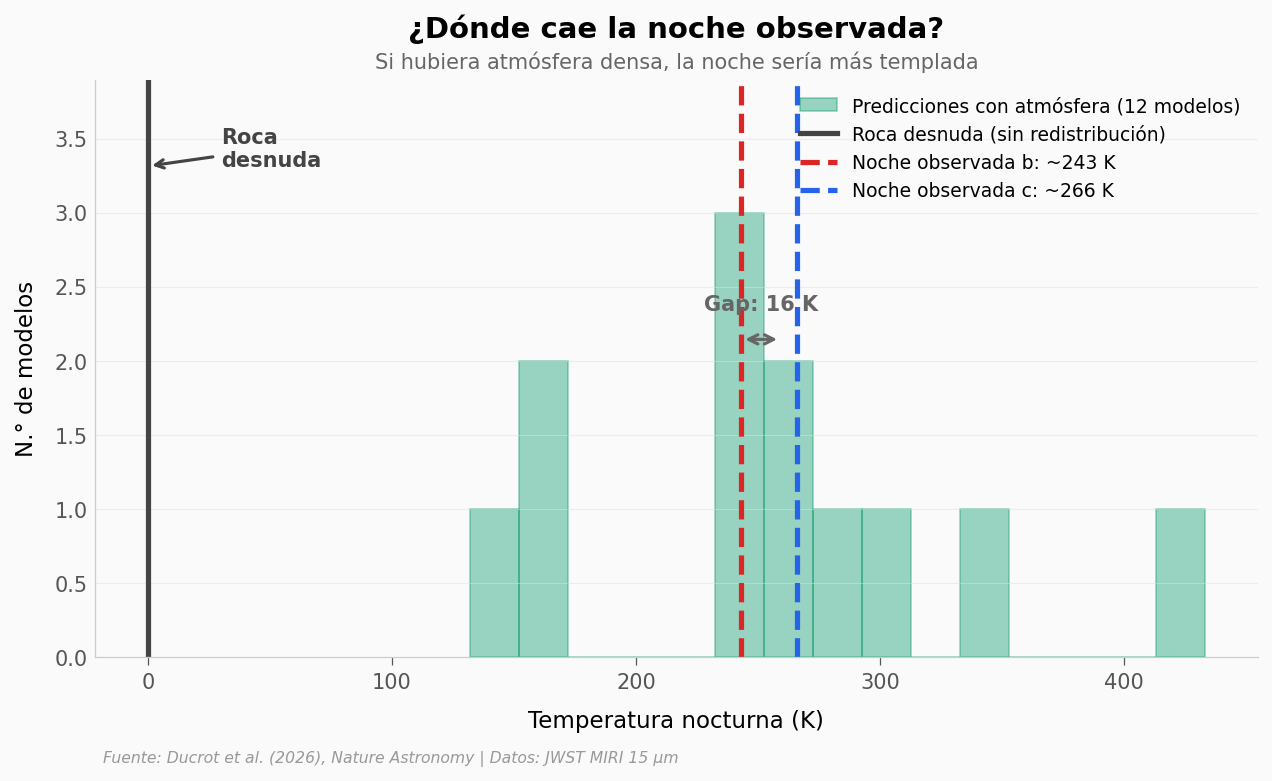

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Night temperatures from different atmospheric models (SM Table 6)
models_night_b = clima[clima['planet'] == 'b']['T_night'].values
models_night_c = clima[clima['planet'] == 'c']['T_night'].values
all_model_nights = np.concatenate([models_night_b, models_night_c])

# Histogram of model predictions
n, bins, patches = ax.hist(all_model_nights, bins=15, color=COLOR_MODELO, alpha=0.4,
                           edgecolor=COLOR_MODELO, linewidth=0.8,
                           label='Predicciones con atmósfera (12 modelos)')

y_max = n.max() * 1.3
ax.set_ylim(0, y_max)

# Bare rock prediction (T_night ≈ 0 for tidally locked)
ax.axvline(x=0, color='#444444', linewidth=2.5, linestyle='-',
           label='Roca desnuda (sin redistribución)')
ax.annotate('Roca\ndesnuda', xy=(0, y_max*0.85), xytext=(30, y_max*0.85),
            fontsize=10, fontweight='bold', color='#444444',
            arrowprops=dict(arrowstyle='->', color='#444444', lw=1.5))

# Observed night temperatures
ax.axvline(x=T_NIGHT_B_MAX, color=COLOR_B, linewidth=2.5, linestyle='--',
           label=f'Noche observada b: ~{T_NIGHT_B_MAX} K')
ax.axvline(x=T_NIGHT_C, color=COLOR_C, linewidth=2.5, linestyle='--',
           label=f'Noche observada c: ~{T_NIGHT_C} K')

# Arrow showing how far observed is from atmosphere predictions
median_model = np.median(all_model_nights)
ax.annotate('', xy=(T_NIGHT_B_MAX, y_max*0.55), xytext=(median_model, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((T_NIGHT_B_MAX + median_model)/2, y_max*0.60,
        f'Gap: {median_model - T_NIGHT_B_MAX:.0f} K',
        fontsize=10, color='#666666', ha='center', fontweight='bold')

ax.set_xlabel('Temperatura nocturna (K)', fontsize=11)
ax.set_ylabel('N.° de modelos', fontsize=11)
ax.set_title('¿Dónde cae la noche observada?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Si hubiera atmósfera densa, la noche sería más templada',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_nocturna.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| TRAPPIST-1 b tiene T diurna de ~490 K | ✅ | 490 ± 17 K (abstract). Rango entre análisis: 472–508 K. Todos consistentes dentro de 2σ |
| TRAPPIST-1 b no tiene emisión nocturna significativa | ✅ | ZH: T_night = 220–243 K con error grande (±35–40 K). ED: T_night ≤ 217 K (uno consistente con 0 K) |
| TRAPPIST-1 c tiene T diurna de ~369 K | ✅ | 369 ± 23 K (abstract). Rango entre análisis: 349–388 K |
| Presiones >1 bar descartadas para ambos | ✅ | Modelos con 10 bar predicen T_night = 300–340 K. Observado: ≤243 K (b), ~266 K (c). Gap de ~34 K (c) a ~97 K (b) |
| TRAPPIST-1 c podría tener atmósfera tenue de O₂ | ⚠️ | "Consistent with either a tenuous, oxygen-rich atmosphere **or** an equally airless surface". No distinguible con estos datos |
| Los planetas perdieron sus atmósferas por la radiación estelar | ⚠️ | El paper dice "suggest divergent evolutionary pathways" — es hipótesis, no medición directa. Los datos muestran ausencia de atmósfera, no la causa |

> **Limitaciones:** (1) Los análisis asumen rotación síncrona (siempre la misma cara hacia la estrella). (2) La conversión flujo → temperatura depende de la emissividad asumida. (3) Una atmósfera extremadamente tenue (<0,1 bar) no es descartable para ninguno de los dos planetas. (4) Los datos son de un solo filtro (15 μm) — más longitudes de onda refinarían las restricciones.

## Ahora tú

Tres ideas para explorar:

1. **¿Qué pasa si cambias la emissividad?** La temperatura de brillo depende de cuánto emite la superficie. Prueba recalcular con emissividad 0.9 vs 0.5. Pista: `T_bright = T_observado * emissividad^(-0.25)`.

2. **¿Cuánta atmósfera toleran los datos?** El modelo con O₂ a 0,1 bar tiene σ = 1,4 para el planeta b. ¿A qué presión el σ sube a 3 (descartado a 3σ)?

3. **¿Cómo se compara con Mercurio?** Mercurio también carece de atmósfera y tiene T_day ≈ 700 K, T_night ≈ 100 K. ¿Es proporcional al que recibiría si orbitara TRAPPIST-1 en vez del Sol?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto redistribuiría el calor una atmósfera?
# El factor de redistribución f va de 1/4 (redistribución total) a 2/3 (cero redistribución)

import numpy as np

T_star = T_STAR  # K
a_b = 0.01153    # semi-eje mayor planeta b (AU)
a_c = 0.01580    # semi-eje mayor planeta c (AU)
R_star = 0.1192  # Radio estelar (R_sol)

AU_to_Rsol = 215.03  # 1 AU en radios solares

print("Temperatura de equilibrio según redistribución de calor:")
print(f"{'f':>6} {'T_eq b (K)':>12} {'T_eq c (K)':>12} {'Interpretación'}")
print("-" * 65)
for f, desc in [(2/3, 'Sin redistribución (roca)'),
                (1/2, 'Solo hemisferio día'),
                (1/4, 'Redistribución total (atmósfera)')]:
    R_star_AU = R_star / AU_to_Rsol  # Convertir R_star a AU
    T_eq_b = T_star * np.sqrt(R_star_AU / (2 * a_b)) * f**0.25
    T_eq_c = T_star * np.sqrt(R_star_AU / (2 * a_c)) * f**0.25
    print(f"{f:>6.3f} {T_eq_b:>12.0f} {T_eq_c:>12.0f} {desc}")

print(f"\nObservado: T_day b = {T_DAY_B} K, T_day c = {T_DAY_C} K")
print("→ Compara con la fila f = 2/3 (sin redistribución): más cercano = más parecido a roca")

Temperatura de equilibrio según redistribución de calor:
     f   T_eq b (K)   T_eq c (K) Interpretación
-----------------------------------------------------------------
 0.667          359          307 Sin redistribución (roca)
 0.500          335          286 Solo hemisferio día
 0.250          281          240 Redistribución total (atmósfera)

Observado: T_day b = 490 K, T_day c = 369 K
→ Compara con la fila f = 2/3 (sin redistribución): más cercano = más parecido a roca


---

**Datos:** JWST MIRI F1500W, programas GO 3077, GO 1177, GO 2304. Disponibles en [MAST](https://mast.stsci.edu). Source Data y Supplementary Materials de Nature Astronomy.

**Paper:** Ducrot, E., Gillon, M., Demory, B.-O. *et al.* No thick atmosphere around TRAPPIST-1 b and c from JWST thermal phase curves. *Nature Astronomy* (2026). DOI: [10.1038/s41550-026-02806-9](https://doi.org/10.1038/s41550-026-02806-9)

**Licencia datos:** Los datos supplementary de Nature están bajo los términos de acceso de Springer Nature.

**Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com) | [GitHub](https://github.com/Ciencia-a-Mordiscos/lab)